# FGTV emissions charts (smoothed with HP filter)

Two charts from `decomposed_ssp_output.csv`, both filtered with the same Hodrick-Prescott smoother used in the R post-processing pipeline (anchored to the first observed year, non-negative).

1. **FGTV emissions by component** — flaring + venting + fugitive (dtp) per strategy.
2. **FGTV emissions by gas** — CO2 + CH4 + N2O per strategy, replicating the CCD "emissions by gas" stack.

Strategy mapping:
- `6003` BAU
- `6004` Unconditional NDC (ZRF)
- `6005` Conditional NDC


In [1]:
import pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from statsmodels.tsa.filters.hp_filter import hpfilter

# Latest run by default (override RUN_DIR below to pin a specific run)
RUNS_ROOT = Path('/Users/fabianfuentes/git/ssp_libya/ssp_modeling/ssp_run_output')
RUN_DIR = sorted(RUNS_ROOT.glob('sisepuede_results_sisepuede_run_*'))[-1]
print('Run dir:', RUN_DIR.name)

df = pd.read_csv(RUN_DIR / 'decomposed_ssp_output.csv')
att = pd.read_csv(RUN_DIR / 'ATTRIBUTE_PRIMARY.csv')
df = df.merge(att[['primary_id','strategy_id']], on='primary_id')
df['year'] = df['time_period'] + 2015
df = df[df.strategy_id != 0].copy()   # drop BASE
print('strategies:', sorted(df.strategy_id.unique()), '| years:', df.year.min(), '->', df.year.max())

STRATEGY_NAMES = {6003: 'BAU', 6004: 'Unconditional NDC (ZRF)', 6005: 'Conditional NDC'}
STRATEGY_ORDER = [6003, 6004, 6005]
LAMBDA_HP = 1600   # matches R post-processing default for Energy CH4/CO2


Run dir: sisepuede_results_sisepuede_run_2026-04-29T23;21;32.174702
strategies: [np.int64(6003), np.int64(6004), np.int64(6005)] | years: 2023 -> 2050


## HP filter helper

Hodrick-Prescott smoother, ported from `output_postprocessing/scr/data_prep_new_mapping.r::hp_filter_subsec`:

1. Apply `hpfilter` with `freq=lambda` to the per-strategy series.
2. Floor the trend at 0 (non-negative).
3. Shift so the smoothed series passes exactly through the first observed value (anchor).
4. Floor again, then re-pin the first point.


In [2]:
def hp_smooth(series: pd.Series, lambda_hp: float = LAMBDA_HP) -> pd.Series:
    """Anchored, non-negative HP trend matching the R hp_filter_subsec output."""
    s = series.astype(float).sort_index()
    if len(s) < 2:
        return s.copy()
    _, trend = hpfilter(s.values, lamb=lambda_hp)
    sm = np.maximum(trend, 0.0)
    shift = s.values[0] - sm[0]
    sm = np.maximum(sm + shift, 0.0)
    sm[0] = s.values[0]
    return pd.Series(sm, index=s.index, name=s.name)


def smooth_by_strategy(df_long: pd.DataFrame, value_cols, lambda_hp: float = LAMBDA_HP) -> pd.DataFrame:
    """Apply hp_smooth to each value_col within each strategy_id, indexed by year."""
    out = df_long.copy()
    for col in value_cols:
        for sid, sub in out.groupby('strategy_id'):
            s = sub.set_index('year')[col]
            sm = hp_smooth(s, lambda_hp = lambda_hp)
            out.loc[sub.index, col] = out.loc[sub.index, 'year'].map(sm)
    return out


## 1 — FGTV emissions by component (flaring + venting + dtp)


In [3]:
fgtv_cols = [c for c in df.columns if c.startswith('emission_co2e_') and '_fgtv_' in c and c != 'emission_co2e_subsector_total_fgtv']
flar_cols = [c for c in fgtv_cols if '_fgtv_flaring_' in c]
vent_cols = [c for c in fgtv_cols if '_fgtv_venting_' in c]
dtp_cols  = [c for c in fgtv_cols if '_fgtv_dtp_' in c]
print(f'flaring cols: {len(flar_cols)} | venting: {len(vent_cols)} | dtp: {len(dtp_cols)}')

comp = df[['strategy_id','year']].copy()
comp['flaring'] = df[flar_cols].sum(axis=1)
comp['venting'] = df[vent_cols].sum(axis=1)
comp['dtp']     = df[dtp_cols].sum(axis=1)
comp['total']   = comp[['flaring','venting','dtp']].sum(axis=1)

comp_sm = smooth_by_strategy(comp, ['flaring','venting','dtp','total'], lambda_hp = LAMBDA_HP)
comp_sm.head()


flaring cols: 12 | venting: 12 | dtp: 12


,strategy_id,year,flaring,venting,dtp,total
0,6003,2023,6.267337,15.684255,5.076407,27.028000
1,6003,2024,7.138592,15.568561,5.037076,27.744230
2,6003,2025,8.010527,15.450191,4.996983,28.457701
3,6003,2026,8.883782,15.323396,4.954494,29.161672
4,6003,2027,9.759139,15.181228,4.907695,29.848062


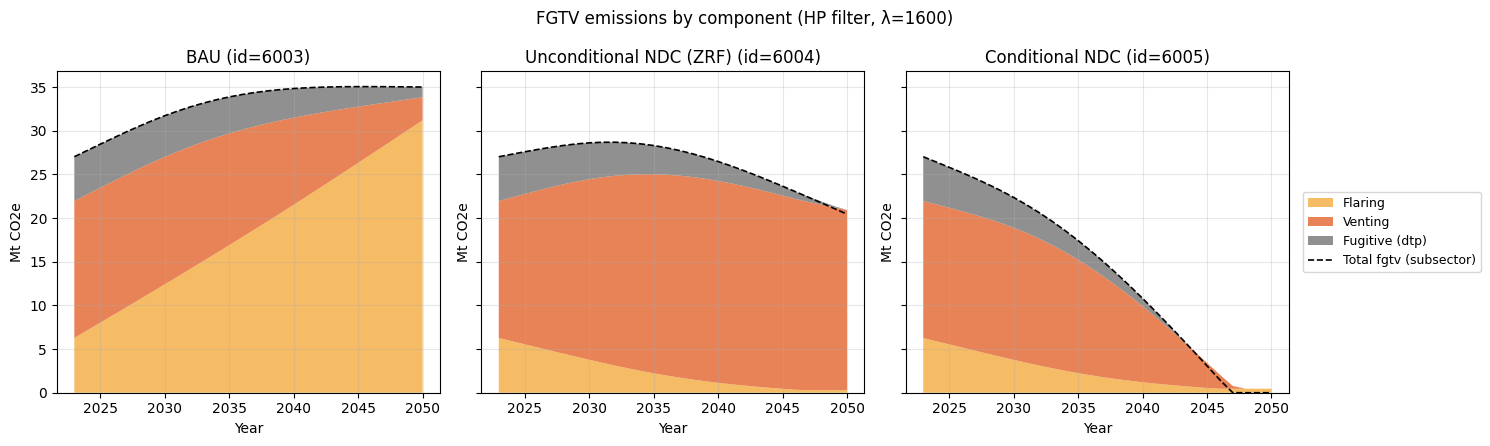

In [4]:
comp_colors = {'flaring': '#f5b04a', 'venting': '#e36d3a', 'dtp': '#7d7d7d'}
strategies_all = [s for s in STRATEGY_ORDER if s in comp_sm.strategy_id.unique()]
fig, axes = plt.subplots(1, len(strategies_all), figsize=(5.0*len(strategies_all), 4.5), sharey=True)
if len(strategies_all) == 1: axes = [axes]
for ax, sid in zip(axes, strategies_all):
    sub = comp_sm[comp_sm.strategy_id == sid].set_index('year').sort_index()
    ax.stackplot(sub.index, sub['flaring'], sub['venting'], sub['dtp'],
                 labels=['Flaring','Venting','Fugitive (dtp)'],
                 colors=[comp_colors['flaring'], comp_colors['venting'], comp_colors['dtp']], alpha=0.85)
    ax.plot(sub.index, sub['total'], 'k--', lw=1.2, label='Total fgtv (subsector)')
    ax.set_title(f"{STRATEGY_NAMES.get(sid, sid)} (id={sid})")
    ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2e'); ax.grid(alpha=0.3)
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9)
fig.suptitle(f'FGTV emissions by component (HP filter, λ={LAMBDA_HP})')
plt.tight_layout(); plt.show()


## 2 — FGTV emissions by gas (CO2 + CH4 + N2O)

Same FGTV totals, but split by greenhouse gas (in CO2e). Replicates the CCD "emissions by gas" stacked area chart, scoped to FGTV only.


In [5]:
co2_cols = [c for c in fgtv_cols if c.startswith('emission_co2e_co2_fgtv_')]
ch4_cols = [c for c in fgtv_cols if c.startswith('emission_co2e_ch4_fgtv_')]
n2o_cols = [c for c in fgtv_cols if c.startswith('emission_co2e_n2o_fgtv_')]
print(f'CO2 cols: {len(co2_cols)} | CH4 cols: {len(ch4_cols)} | N2O cols: {len(n2o_cols)}')

gas = df[['strategy_id','year']].copy()
gas['CO2'] = df[co2_cols].sum(axis=1)
gas['CH4'] = df[ch4_cols].sum(axis=1)
gas['N2O + F-gases'] = df[n2o_cols].sum(axis=1)   # FGTV has no F-gases; column kept for visual parity with CCD chart
gas['total'] = gas[['CO2','CH4','N2O + F-gases']].sum(axis=1)

gas_sm = smooth_by_strategy(gas, ['CO2','CH4','N2O + F-gases','total'], lambda_hp = LAMBDA_HP)
gas_sm.head()


CO2 cols: 12 | CH4 cols: 12 | N2O cols: 12


,strategy_id,year,CO2,CH4,N2O + F-gases,total
0,6003,2023,7.804993,19.193919,0.029088,27.028000
1,6003,2024,8.664692,19.050415,0.029122,27.744230
2,6003,2025,9.524816,18.903717,0.029169,28.457701
3,6003,2026,10.385456,18.746979,0.029238,29.161672
4,6003,2027,11.246719,18.572007,0.029337,29.848062


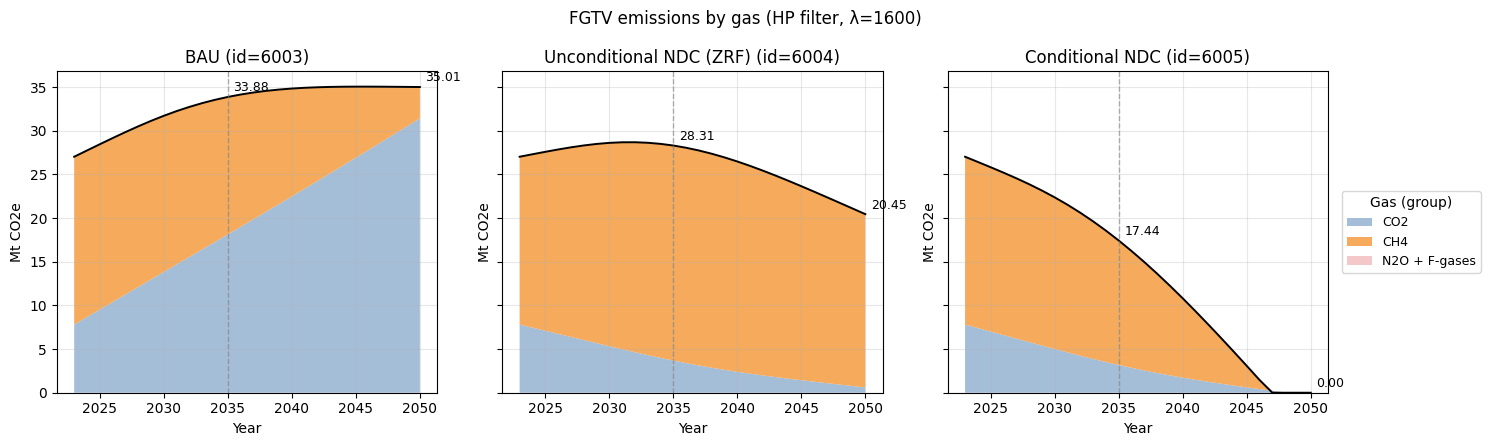

In [6]:
gas_colors = {'CO2': '#9bb7d4', 'CH4': '#f4a14a', 'N2O + F-gases': '#f3c1c4'}
fig, axes = plt.subplots(1, len(strategies_all), figsize=(5.0*len(strategies_all), 4.5), sharey=True)
if len(strategies_all) == 1: axes = [axes]
anchor_year = 2035
for ax, sid in zip(axes, strategies_all):
    sub = gas_sm[gas_sm.strategy_id == sid].set_index('year').sort_index()
    ax.stackplot(sub.index, sub['CO2'], sub['CH4'], sub['N2O + F-gases'],
                 labels=['CO2','CH4','N2O + F-gases'],
                 colors=[gas_colors['CO2'], gas_colors['CH4'], gas_colors['N2O + F-gases']], alpha=0.9)
    ax.plot(sub.index, sub['total'], 'k-', lw=1.4)
    if anchor_year in sub.index:
        ax.axvline(anchor_year, color='gray', ls='--', lw=1, alpha=0.6)
        ax.annotate(f"{sub.loc[anchor_year,'total']:.2f}", xy=(anchor_year, sub.loc[anchor_year,'total']),
                    xytext=(4, 4), textcoords='offset points', fontsize=9)
    last_year = sub.index.max()
    ax.annotate(f"{sub.loc[last_year,'total']:.2f}", xy=(last_year, sub.loc[last_year,'total']),
                xytext=(4, 4), textcoords='offset points', fontsize=9)
    ax.set_title(f"{STRATEGY_NAMES.get(sid, sid)} (id={sid})")
    ax.set_xlabel('Year'); ax.set_ylabel('Mt CO2e'); ax.grid(alpha=0.3)
axes[-1].legend(loc='center left', bbox_to_anchor=(1.02, 0.5), fontsize=9, title='Gas (group)')
fig.suptitle(f'FGTV emissions by gas (HP filter, λ={LAMBDA_HP})')
plt.tight_layout(); plt.show()


## 3 — FGTV volumes (Bcm, MMcfd) and gas recovery

Convert the FGTV emissions to natural-gas-equivalent volumes using GGFR / IEA conventions and calibrate to the Libya CCD March 2026 anchors (2024 BAU: flaring 6.30 Bcm, venting 0.98 Bcm, fugitive 0.33 Bcm).

`gas_recovery` is exported in two complementary units, each internally consistent with stack conservation:

```
gas_recovery_bcm    = BAU(F+V+Fu)_bcm   - scenario(F+V+Fu)_bcm     # physical volume diff
gas_recovery_mtco2e = BAU(F+V+Fu)_mtco2e - scenario(F+V+Fu)_mtco2e # climate-weighted diff
```

Use the **Bcm** form for charts in physical-volume units (flared/vented/leaked m³); use the **MtCO2e** form for charts in climate-impact units. Mixing the two breaks stack conservation because vented/leaked CH4 carries ~7× more CO2e per Bcm than flared CO2.

Both forms are zero for BAU rows by construction.


In [7]:
# Physical conversion constants (15 degC, 1 atm)
KG_CO2_PER_M3_FLARED_GAS = 2.54   # composition-weighted CO2 yield from associated gas combustion
KG_CH4_PER_M3_PURE       = 0.717  # density of pure CH4 at NTP
NG_CH4_VOLUME_FRACTION   = 0.95   # vented/leaked stream ~95% CH4 by volume
GWP_CH4                  = 27.9   # IPCC AR6 100-year, matches sisepuede attribute_gas
MMCFD_PER_BCM            = 96.75  # 1 Bcm/year continuous flow ≈ 96.75 MMcfd

# 2024 BAU report anchors (Libya CCD, World Bank, March 2026)
TARGET_2024_BAU_BCM = {'flaring': 6.30, 'venting': 0.981, 'fugitive': 0.334}

def co2_emissions_mt_to_volume_bcm(em_mt):
    """Flaring: tonnes CO2 -> Bcm of associated gas combusted."""
    return em_mt * 1e9 / KG_CO2_PER_M3_FLARED_GAS / 1e9

def ch4_emissions_co2eq_mt_to_volume_bcm(em_mt):
    """Venting/fugitive: Mt CO2eq of CH4 -> Bcm of natural gas escaped."""
    return em_mt * 1e9 / GWP_CH4 / KG_CH4_PER_M3_PURE / NG_CH4_VOLUME_FRACTION / 1e9

# Use CO2 emissions for flaring (combustion product), CH4 for venting/fugitive (escape products).
flar_co2_cols = [c for c in df.columns if c.startswith('emission_co2e_co2_fgtv_flaring_')]
vent_ch4_cols = [c for c in df.columns if c.startswith('emission_co2e_ch4_fgtv_venting_')]
dtp_ch4_cols  = [c for c in df.columns if c.startswith('emission_co2e_ch4_fgtv_dtp_')]

vol = df[['strategy_id','year']].copy()
vol['flaring_bcm']  = co2_emissions_mt_to_volume_bcm(df[flar_co2_cols].sum(axis=1))
vol['venting_bcm']  = ch4_emissions_co2eq_mt_to_volume_bcm(df[vent_ch4_cols].sum(axis=1))
vol['fugitive_bcm'] = ch4_emissions_co2eq_mt_to_volume_bcm(df[dtp_ch4_cols].sum(axis=1))

# Production volumes (oil and gas) from PJ + density.
for fuel in ['crude','natural_gas']:
    prod_col = f'prod_enfu_fuel_{fuel}_pj'
    dens_col = f'energydensity_enfu_mj_per_litre_fuel_{fuel}'
    if prod_col in df.columns and dens_col in df.columns:
        density = df[dens_col].replace(0, np.nan)
        vol[f'production_{fuel}_bcm'] = (df[prod_col] * 1e6 / density / 1e9).fillna(0.0)

# HP-smooth raw volumes per strategy, then calibrate AFTER smoothing so the
# 2024 BAU smoothed value matches the report exactly.
vol_sm = smooth_by_strategy(
    vol,
    ['flaring_bcm','venting_bcm','fugitive_bcm','production_crude_bcm','production_natural_gas_bcm'],
    lambda_hp = LAMBDA_HP,
)

calibration = {}
for path in ['flaring','venting','fugitive']:
    smoothed_2024_bau = vol_sm.loc[
        (vol_sm.strategy_id == 6003) & (vol_sm.year == 2024), f'{path}_bcm'
    ].iloc[0]
    factor = TARGET_2024_BAU_BCM[path] / smoothed_2024_bau if smoothed_2024_bau > 0 else 1.0
    calibration[path] = factor
    vol_sm[f'{path}_bcm'] *= factor
print('Calibration factors (smoothed 2024 BAU -> CCD 2024 target):',
      {k: round(v, 3) for k, v in calibration.items()})

# Implied calibrated MtCO2e per pathway.
vol_sm['flaring_mtco2e']  = vol_sm['flaring_bcm']  * 1e9 * KG_CO2_PER_M3_FLARED_GAS / 1e9
vol_sm['venting_mtco2e']  = vol_sm['venting_bcm']  * 1e9 * KG_CH4_PER_M3_PURE * NG_CH4_VOLUME_FRACTION * GWP_CH4 / 1e9
vol_sm['fugitive_mtco2e'] = vol_sm['fugitive_bcm'] * 1e9 * KG_CH4_PER_M3_PURE * NG_CH4_VOLUME_FRACTION * GWP_CH4 / 1e9
vol_sm['fgtv_total_bcm']    = vol_sm[['flaring_bcm','venting_bcm','fugitive_bcm']].sum(axis=1)
vol_sm['fgtv_total_mtco2e'] = vol_sm[['flaring_mtco2e','venting_mtco2e','fugitive_mtco2e']].sum(axis=1)

# gas_recovery in two units, each internally consistent. Use the Bcm form
# in physical-volume charts (stack conservation, no overshoot vs BAU); use
# the MtCO2e form in climate-impact charts (clear scenario differentiation).
bau_total_bcm    = vol_sm.loc[vol_sm.strategy_id == 6003].set_index('year')['fgtv_total_bcm']
bau_total_mtco2e = vol_sm.loc[vol_sm.strategy_id == 6003].set_index('year')['fgtv_total_mtco2e']

vol_sm['fgtv_total_bau_bcm']    = vol_sm['year'].map(bau_total_bcm)
vol_sm['fgtv_total_bau_mtco2e'] = vol_sm['year'].map(bau_total_mtco2e)
vol_sm['gas_recovery_bcm']      = vol_sm['fgtv_total_bau_bcm']    - vol_sm['fgtv_total_bcm']
vol_sm['gas_recovery_mtco2e']   = vol_sm['fgtv_total_bau_mtco2e'] - vol_sm['fgtv_total_mtco2e']

# MMcfd convenience columns (volume-equivalent only; MtCO2e doesn't translate).
for c in ['flaring','venting','fugitive','gas_recovery']:
    vol_sm[f'{c}_mmcfd'] = vol_sm[f'{c}_bcm'] * MMCFD_PER_BCM

vol_sm.head()


Calibration factors (smoothed 2024 BAU -> CCD 2024 target): {'flaring': np.float64(2.254), 'venting': np.float64(1.239), 'fugitive': np.float64(1.599)}


,strategy_id,year,flaring_bcm,venting_bcm,fugitive_bcm,production_crude_bcm,production_natural_gas_bcm,flaring_mtco2e,venting_mtco2e,fugitive_mtco2e,fgtv_total_bcm,fgtv_total_mtco2e,fgtv_total_bau_bcm,fgtv_total_bau_mtco2e,gas_recovery_bcm,gas_recovery_mtco2e,flaring_mmcfd,venting_mmcfd,fugitive_mmcfd,gas_recovery_mmcfd
0,6003,2023,5.530846,0.988274,0.337007,0.065944,7.210946,14.048349,18.781245,6.404502,6.856127,39.234097,6.856127,39.234097,0.0,0.0,535.109367,95.615520,32.605389,0.0
1,6003,2024,6.300000,0.981000,0.334000,0.068685,7.770143,16.002000,18.643007,6.347364,7.615000,40.992372,7.615000,40.992372,0.0,0.0,609.525000,94.911750,32.314500,0.0
2,6003,2025,7.069751,0.973556,0.330944,0.071420,8.328417,17.957168,18.501537,6.289284,8.374251,42.747989,8.374251,42.747989,0.0,0.0,683.998424,94.191522,32.018814,0.0
3,6003,2026,7.840664,0.965577,0.327732,0.074137,8.883664,19.915286,18.349914,6.228244,9.133973,44.493445,9.133973,44.493445,0.0,0.0,758.584223,93.419611,31.708057,0.0
4,6003,2027,8.613424,0.956625,0.324242,0.076817,9.433001,21.878097,18.179788,6.161913,9.894291,46.219798,9.894291,46.219798,0.0,0.0,833.348783,92.553495,31.370366,0.0


In [8]:
# Sanity check: 2024 BAU should match the report; both gas_recovery flavors
# should be 0 for BAU and reflect the right diff for the scenarios.
sanity = vol_sm[(vol_sm.year.isin([2024, 2030, 2035, 2050])) & (vol_sm.strategy_id.isin(STRATEGY_ORDER))][[
    'year','strategy_id',
    'flaring_bcm','venting_bcm','fugitive_bcm',
    'fgtv_total_bcm','gas_recovery_bcm',
    'fgtv_total_mtco2e','gas_recovery_mtco2e',
]].copy()
sanity['strategy'] = sanity['strategy_id'].map(STRATEGY_NAMES)
sanity = sanity.round(3)
print(sanity.sort_values(['year','strategy_id']).drop(columns='strategy_id').to_string(index=False))

# Conservation check: scenario_F+V+Fu_bcm + gas_recovery_bcm should equal BAU_F+V+Fu_bcm.
print('\nStack conservation (Bcm) — scenario_total + gas_recovery should equal BAU_total:')
for sid, name in STRATEGY_NAMES.items():
    sub = vol_sm[(vol_sm.strategy_id == sid) & (vol_sm.year == 2050)]
    if sub.empty: continue
    s = sub.iloc[0]
    print(f'  {name:25s} 2050: {s["fgtv_total_bcm"]:.3f} + {s["gas_recovery_bcm"]:.3f} = {s["fgtv_total_bcm"] + s["gas_recovery_bcm"]:.3f}  (BAU = {s["fgtv_total_bau_bcm"]:.3f})')

print('\nLibya CCD March 2026 anchors:')
print('  2024 BAU flaring  6.30 Bcm | venting 0.98 Bcm | fugitive 0.33 Bcm')
print('  2030 BAU flaring ~10.25 Bcm (~991 MMcfd)')
print('  2030 ZRF flaring  0.94 Bcm (~91 MMcfd)')


 year  flaring_bcm  venting_bcm  fugitive_bcm  fgtv_total_bcm  gas_recovery_bcm  fgtv_total_mtco2e  gas_recovery_mtco2e                strategy
 2024        6.300        0.981         0.334           7.615             0.000             40.992                0.000                     BAU
 2024        5.214        1.036         0.329           6.579             1.036             39.183                1.809 Unconditional NDC (ZRF)
 2024        5.211        0.987         0.322           6.520             1.095             38.113                2.879         Conditional NDC
 2030       10.948        0.920         0.311          12.178             0.000             51.189                0.000                     BAU
 2030        3.334        1.303         0.273           4.911             7.267             38.433               12.756 Unconditional NDC (ZRF)
 2030        3.325        0.954         0.227           4.506             7.672             30.880               20.309         Conditio

## Export for Tableau

Long-format CSV with the same schema used by the existing Tableau workbook: `year, strategy_id, strategy_name, chart, metric, facility_type, value, units`. Smoothed values are exported (HP filter applied).

- `chart='fgtv_components'`: emissions by component (Mt CO2e).
- `chart='fgtv_by_gas'`: emissions by gas (Mt CO2e).
- `chart='fgtv_volumes'`: volumes (Bcm + MMcfd) and the corresponding MtCO2e per pathway. `gas_recovery` is exported in **both** units: `gas_recovery_vol_bcm` (BAU minus scenario in physical volume — stack-conserves in Bcm charts) and `gas_recovery_mt_co2e` (BAU minus scenario in CO2e — climate-weighted, stack-conserves in MtCO2e charts). Pick the one that matches your y-axis.

Saved to `ssp_modeling/tableau/data/oilgas_ccd_charts_libya.csv`.


In [9]:
rows = []

# Chart A: FGTV components — emissions (Mt CO2e), smoothed
comp_metric_map = {
    'flaring': ('flar_emis_mt_co2e', 'Mt CO2e'),
    'venting': ('vent_ch4_mt_co2e',  'Mt CO2e'),
    'dtp':     ('dtp_ch4_mt_co2e',   'Mt CO2e'),
    'total':   ('total_fgtv_mt_co2e','Mt CO2e'),
}
for _, r in comp_sm.iterrows():
    sid = int(r['strategy_id'])
    for col, (metric, units) in comp_metric_map.items():
        rows.append({
            'year': int(r['year']),
            'strategy_id': sid,
            'strategy_name': STRATEGY_NAMES.get(sid, str(sid)),
            'chart': 'fgtv_components',
            'metric': metric,
            'facility_type': 'All',
            'value': float(r[col]),
            'units': units,
        })

# Chart B: FGTV by gas — emissions (Mt CO2e), smoothed
gas_metric_map = {
    'CO2':            ('fgtv_co2_mt_co2e',         'Mt CO2e'),
    'CH4':            ('fgtv_ch4_mt_co2e',         'Mt CO2e'),
    'N2O + F-gases':  ('fgtv_n2o_fgases_mt_co2e',  'Mt CO2e'),
    'total':          ('total_fgtv_mt_co2e',       'Mt CO2e'),
}
for _, r in gas_sm.iterrows():
    sid = int(r['strategy_id'])
    for col, (metric, units) in gas_metric_map.items():
        rows.append({
            'year': int(r['year']),
            'strategy_id': sid,
            'strategy_name': STRATEGY_NAMES.get(sid, str(sid)),
            'chart': 'fgtv_by_gas',
            'metric': metric,
            'facility_type': 'All',
            'value': float(r[col]),
            'units': units,
        })

# Chart C: FGTV volumes (Bcm + MMcfd + MtCO2e). gas_recovery exists in both
# Bcm (physical-volume diff, conserves on Bcm chart) and MtCO2e (climate
# diff, conserves on MtCO2e chart) — pick the matching one for each chart.
vol_metric_map = {
    'flaring_bcm':              ('flaring_vol_bcm',           'Bcm'),
    'venting_bcm':              ('venting_vol_bcm',           'Bcm'),
    'fugitive_bcm':             ('fugitive_vol_bcm',          'Bcm'),
    'production_crude_bcm':     ('production_oil_vol_bcm',    'Bcm'),
    'production_natural_gas_bcm':('production_gas_vol_bcm',   'Bcm'),
    'flaring_mmcfd':            ('flaring_vol_mmcfd',         'MMcfd'),
    'venting_mmcfd':            ('venting_vol_mmcfd',         'MMcfd'),
    'fugitive_mmcfd':           ('fugitive_vol_mmcfd',        'MMcfd'),
    'flaring_mtco2e':           ('flaring_emis_mt_co2e',      'Mt CO2e'),
    'venting_mtco2e':           ('venting_emis_mt_co2e',      'Mt CO2e'),
    'fugitive_mtco2e':          ('fugitive_emis_mt_co2e',     'Mt CO2e'),
    'gas_recovery_bcm':         ('gas_recovery_vol_bcm',      'Bcm'),
    'gas_recovery_mmcfd':       ('gas_recovery_vol_mmcfd',    'MMcfd'),
    'gas_recovery_mtco2e':      ('gas_recovery_mt_co2e',      'Mt CO2e'),
}
for _, r in vol_sm.iterrows():
    sid = int(r['strategy_id'])
    for col, (metric, units) in vol_metric_map.items():
        if col not in vol_sm.columns:
            continue
        rows.append({
            'year': int(r['year']),
            'strategy_id': sid,
            'strategy_name': STRATEGY_NAMES.get(sid, str(sid)),
            'chart': 'fgtv_volumes',
            'metric': metric,
            'facility_type': 'All',
            'value': float(r[col]),
            'units': units,
        })

tab = pd.DataFrame(rows, columns=['year','strategy_id','strategy_name','chart','metric','facility_type','value','units'])
out_path = Path('/Users/fabianfuentes/git/ssp_libya/ssp_modeling/tableau/data/oilgas_ccd_charts_libya.csv')
out_path.parent.mkdir(parents=True, exist_ok=True)
tab.to_csv(out_path, index=False)
print(f'Wrote {len(tab)} rows to {out_path}')
print('chart values :', sorted(tab.chart.unique()))
print('metric values:', sorted(tab.metric.unique()))
tab.head()


Wrote 1848 rows to /Users/fabianfuentes/git/ssp_libya/ssp_modeling/tableau/data/oilgas_ccd_charts_libya.csv
chart values : ['fgtv_by_gas', 'fgtv_components', 'fgtv_volumes']
metric values: ['dtp_ch4_mt_co2e', 'fgtv_ch4_mt_co2e', 'fgtv_co2_mt_co2e', 'fgtv_n2o_fgases_mt_co2e', 'flar_emis_mt_co2e', 'flaring_emis_mt_co2e', 'flaring_vol_bcm', 'flaring_vol_mmcfd', 'fugitive_emis_mt_co2e', 'fugitive_vol_bcm', 'fugitive_vol_mmcfd', 'gas_recovery_mt_co2e', 'gas_recovery_vol_bcm', 'gas_recovery_vol_mmcfd', 'production_gas_vol_bcm', 'production_oil_vol_bcm', 'total_fgtv_mt_co2e', 'vent_ch4_mt_co2e', 'venting_emis_mt_co2e', 'venting_vol_bcm', 'venting_vol_mmcfd']


,year,strategy_id,strategy_name,chart,metric,facility_type,value,units
0,2023,6003,BAU,fgtv_components,flar_emis_mt_co2e,All,6.267337,Mt CO2e
1,2023,6003,BAU,fgtv_components,vent_ch4_mt_co2e,All,15.684255,Mt CO2e
2,2023,6003,BAU,fgtv_components,dtp_ch4_mt_co2e,All,5.076407,Mt CO2e
3,2023,6003,BAU,fgtv_components,total_fgtv_mt_co2e,All,27.028000,Mt CO2e
4,2024,6003,BAU,fgtv_components,flar_emis_mt_co2e,All,7.138592,Mt CO2e


## Notes

- `LAMBDA_HP=1600` matches the R post-processing default used for Energy CH4/CO2 series. Use 600 for noisier series, 100 for almost-no-smoothing.
- The first observed year (2023) is anchored exactly to the model output. Smoothing only affects later years.
- The dashed black line on chart 1 is the FGTV subsector total (sanity check: should equal the stacked sum).
